# play0

In [7]:
from drone_tracker import (
    Simulator, SimConfig,
    PController, PIDYawController, PurePursuitLike,
    make_controller,
    compare_runs, print_comparison,
)

## params

In [8]:
config = SimConfig(
    # Timing
    duration= 35.0,       # Total simulation time (seconds)
    sim_hz = 200.0,        # Physics simulation rate (Hz)
    ctrl_hz = 30.0,        # Controller update rate (Hz)
    
    # Initial conditions
    drone_x0 = -2.0,
    drone_y0 = -2.0,
    drone_yaw0_deg = 45.0,
    target_x0 = 10.0,
    target_y0 = 0.0,
    
    # Perception noise (set to 0 for perfect sensing)
    noise_bearing = 0.02,  # Bearing noise std dev (rad)
    noise_range = 0.05 ,   # Range noise std dev (m)
    
    # FCU limits (what the flight controller enforces)
    v_max = 2.0   ,        # Max velocity (m/s)
    a_max = 2.5   ,        # Max acceleration (m/s²)
    yaw_rate_max = 1.5  ,  # Max yaw rate (rad/s)
    
    # Metrics
    capture_radius = 0.7 , # Distance considered "captured"
    
    # Reproducibility
    seed = 1,
)
sim = Simulator(config)

In [9]:
line_config = {
    "speed": 1.0,
    "start": (5, 5),
    "oscillation": 3.0,
    "osc_freq": 0.5
}

## simple run

In [10]:
result = sim.run(controller="p", scenario="line",scenario_kwargs=line_config)


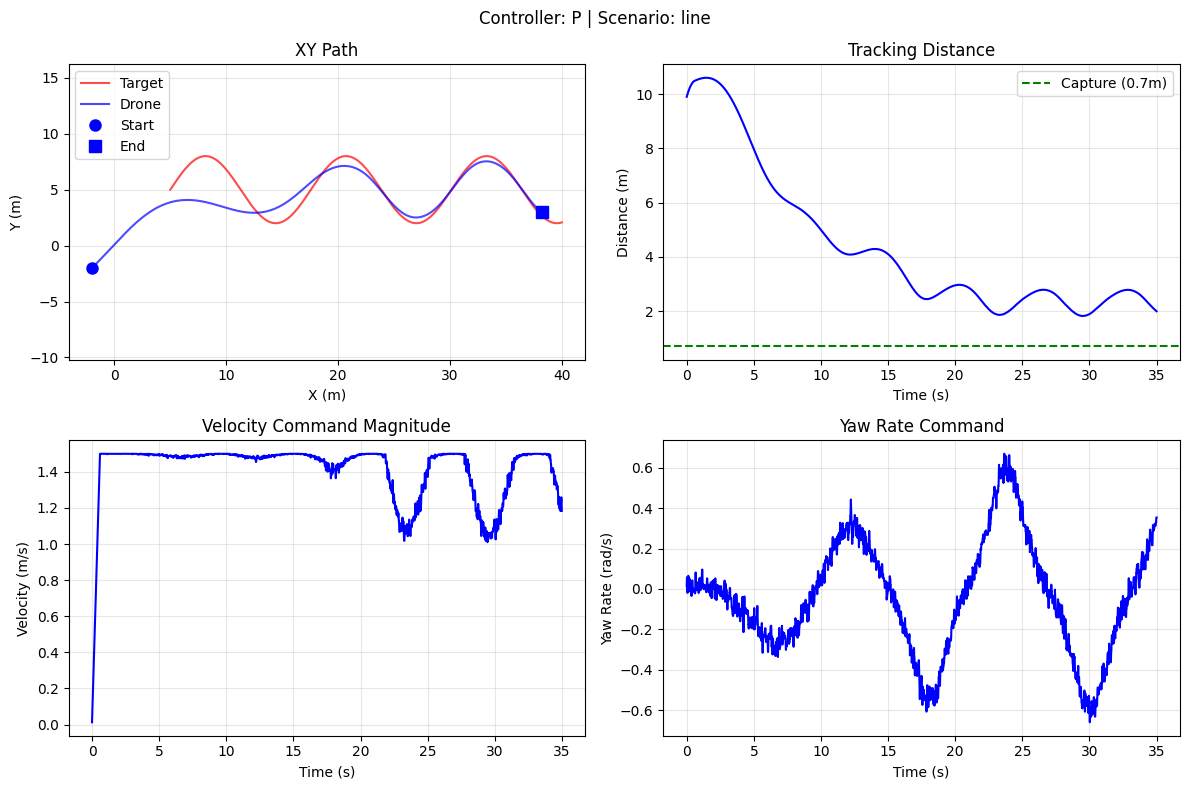

(<Figure size 1200x800 with 4 Axes>,
 array([[<Axes: title={'center': 'XY Path'}, xlabel='X (m)', ylabel='Y (m)'>,
         <Axes: title={'center': 'Tracking Distance'}, xlabel='Time (s)', ylabel='Distance (m)'>],
        [<Axes: title={'center': 'Velocity Command Magnitude'}, xlabel='Time (s)', ylabel='Velocity (m/s)'>,
         <Axes: title={'center': 'Yaw Rate Command'}, xlabel='Time (s)', ylabel='Yaw Rate (rad/s)'>]],
       dtype=object))

In [11]:
sim.plot(result)

In [12]:
print(result.metrics)

Simulation Metrics:
  RMS Distance:      5.111 m
  Min Distance:      1.818 m
  Max Distance:      10.602 m
  Mean Distance:     4.364 m
  Time to Capture:   not captured
  Time in Capture:   0.00 s
  Control Energy (v):   2.037
  Control Energy (yaw): 0.079
